Databricks notebook source
MAGIC %md
MAGIC
MAGIC ## UMAP visualization of patients' diagnoses based on age
MAGIC
MAGIC Note: This visualizes all phenotypes not related to infertility

COMMAND ----------

In [1]:
import os
os.chdir('/Users/fengxie/Documents/Logistic_Regression_Python_Stanford/Logistic_Regression_Python_MI')
from MI_Functions import *

COMMAND ----------

In [2]:
# Restart state after running above for the first time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.core.multiarray
import numpy as np
import os
import re
import scipy
from scipy import stats
from scipy.stats import mstats
from scipy.stats import mannwhitneyu
from scikit_posthocs import posthoc_dunn
import matplotlib
import re

COMMAND ----------

MAGIC %md
MAGIC ## 'Import' functions

COMMAND ----------

MAGIC %run MI_Functions.py

COMMAND ----------

In [3]:
# feature corresponds to column of interest 
feature = 'age bracket'

COMMAND ----------

In [4]:
all_demo_df = pd.read_pickle("male_infertility_validation/tables/umap/demo_all.pkl")

COMMAND ----------

MAGIC %md
MAGIC ## Read in 'X', the 2D representations of patients' diagnoses

COMMAND ----------

In [5]:
X = pd.read_pickle("male_infertility_validation/tables/umap/mi_vas_only.pkl").sort_values(by='index').copy()

COMMAND ----------

MAGIC %md
MAGIC ## Create X_embedded (numpy array)

COMMAND ----------

In [6]:
X_embedded = make_X_embedded(X)

COMMAND ----------

In [7]:
display(X.head(5))

,index,0,1
0,0,-0.397915,-2.422086
1,1,2.224567,-8.332384
2,2,-4.776010,-11.833568
3,3,3.084123,-10.944121
4,4,3.094965,-13.646980


COMMAND ----------

MAGIC %md
MAGIC ## Read in 'y', which preserves each patient's male infertility status (it is not preserved after performing dimensionality reduction) as well as demographic features

COMMAND ----------

In [8]:
y_all = pd.read_pickle("male_infertility_validation/tables/umap/y_all.pkl").sort_values(by='index').copy()

COMMAND ----------

MAGIC  %md
MAGIC ### Convert y (which can be any feature) to series of feature of interest

COMMAND ----------

MAGIC %md
MAGIC #### First, create age_bracket function

COMMAND ----------

In [9]:
def age_bracket(age_series):
  """
  Parameters
  __________
  age_series : pandas Series
    Contains ages of patients

  Returns
  _______
  age_bracket : pandas Series
    Contains age bracket of patients
  """

  if age_series < 30:
    age_bracket = '< 30'
  elif (age_series >= 30) and (age_series < 40):
    age_bracket = '30 - 39'
  elif (age_series >= 40) and (age_series < 50):
    age_bracket = '40 - 49'
  elif (age_series >= 50) and (age_series < 60):
    age_bracket = '50 - 59'
  elif (age_series >= 60) and (age_series < 70):
    age_bracket = '60 - 69'
  elif (age_series >= 70) and (age_series < 80):
    age_bracket = '70 - 79'
  else:
    if age_series >= 80:
      age_bracket = '>= 80'
    else:
      print('Check age')
  
  return age_bracket

COMMAND ----------

In [10]:
# Get quintiles for number of visits
y_all['age bracket'] = y_all['estimated_age'].apply(age_bracket)

In [11]:
y = y_all[feature]

COMMAND ----------

MAGIC %md
MAGIC ## Visualize UMAP

COMMAND ----------

UMAP based on Age Bracket


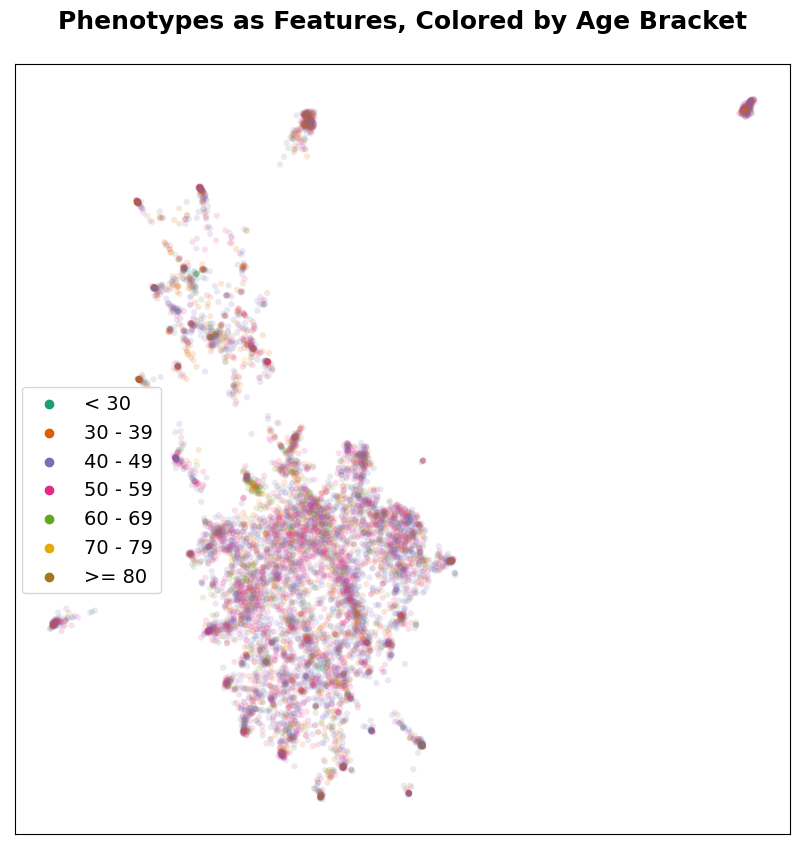

In [12]:
visualize_UMAP_data(X_embedded=X_embedded, 
                    y=y,
                    hue_order=['< 30', 
                               '30 - 39',
                               '40 - 49', 
                               '50 - 59',
                               '60 - 69',  
                               '70 - 79',
                               '>= 80'], 
                    feature=feature.title(),
                    bbox_to_anchor=(0.201, 0.3),
                    alpha=0.15,
                    figure_size=(10, 10),
                    label_axes=False,
                    palette='Dark2',
                    save=True,
                    file_name='fx_umap_age')

COMMAND ----------

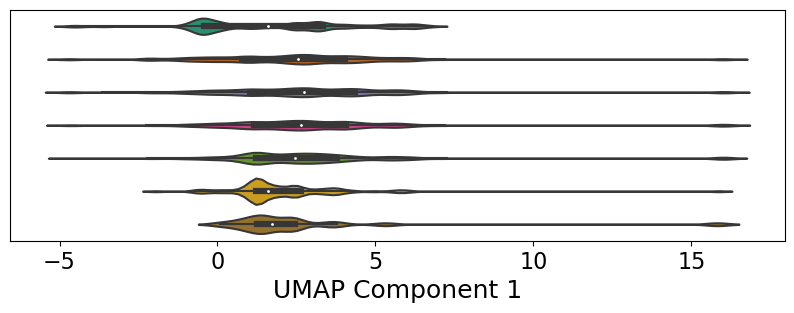

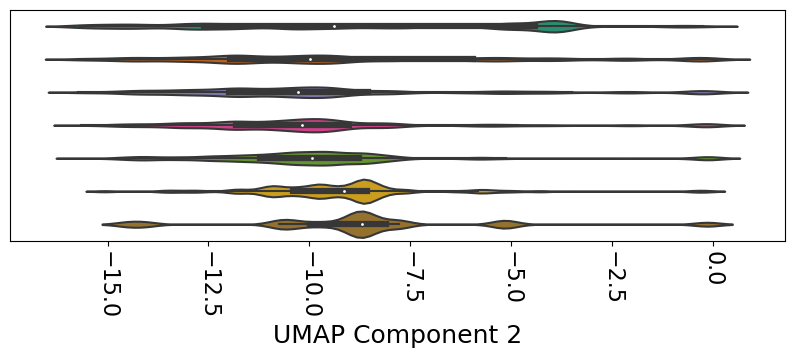

In [13]:
make_UMAP_violin_plots(X_embedded=X_embedded, 
                       y_values=y.values, 
                       order=['< 30', 
                              '30 - 39',
                              '40 - 49', 
                              '50 - 59',
                              '60 - 69',  
                              '70 - 79',
                              '>= 80'],
                       palette='Dark2',
                       save=True,
                       filename_UMAP_1='fx_umap_age_violin1',
                       filename_UMAP_2='fx_umap_age_violin2')

COMMAND ----------

MAGIC %md
MAGIC ## Statistics

COMMAND ----------

MAGIC %md
MAGIC ### Kruskal-Wallis, followed by Dunn's test

COMMAND ----------

In [14]:
save_dunn = True

COMMAND ----------

In [15]:
print(color.BOLD + f"Kruskal-Wallis test" + color.END)
y_categories = y.unique()

Kruskal-Wallis test


In [16]:
print(f"Categories compared: {y.unique()}")
print('\n')

Categories compared: ['40 - 49' '50 - 59' '60 - 69' '70 - 79' '< 30' '30 - 39' '>= 80']




In [17]:
# Create arrays for each category
val1 = X_embedded[y.values == y_categories[0], :]
val1 = convert_UMAP_array_to_df(val1)
val1[feature] = y_categories[0]

In [18]:
val2 = X_embedded[y.values == y_categories[1], :]
val2 = convert_UMAP_array_to_df(val2)
val2[feature] = y_categories[1]

In [19]:
val3 = X_embedded[y.values == y_categories[2], :]
val3 = convert_UMAP_array_to_df(val3)
val3[feature] = y_categories[2]

In [20]:
val4 = X_embedded[y.values == y_categories[3], :]
val4 = convert_UMAP_array_to_df(val4)
val4[feature] = y_categories[3]

In [21]:
val5 = X_embedded[y.values == y_categories[4], :]
val5 = convert_UMAP_array_to_df(val5)
val5[feature] = y_categories[4]

In [22]:
val6 = X_embedded[y.values == y_categories[4], :]
val6 = convert_UMAP_array_to_df(val5)
val6[feature] = y_categories[5]

In [23]:
val7 = X_embedded[y.values == y_categories[4], :]
val7 = convert_UMAP_array_to_df(val5)
val7[feature] = y_categories[6]

In [24]:
# First component
statistic_1, pvalue_1 = mstats.kruskalwallis(np.asarray(val1['axis_1']), 
                                             np.asarray(val2['axis_1']), 
                                             np.asarray(val3['axis_1']), 
                                             np.asarray(val4['axis_1']),
                                             np.asarray(val5['axis_1']),
                                             np.asarray(val6['axis_1']),
                                             np.asarray(val7['axis_1']))

In [25]:
print(f"Kruskal-Wallis Result for First Component: \nStatistic is: {statistic_1} \np-value is: {pvalue_1}")
if pvalue_1 < 0.05:
  print('Significant')
else:
  print('Not Significant')
print('\n')

Kruskal-Wallis Result for First Component: 
Statistic is: 38.059223150081976 
p-value is: 1.0938076098108227e-06
Significant




In [26]:
# Second component
statistic_2, pvalue_2 = mstats.kruskalwallis(np.asarray(val1['axis_2']), 
                                             np.asarray(val2['axis_2']),
                                             np.asarray(val3['axis_2']),
                                             np.asarray(val4['axis_2']),
                                             np.asarray(val5['axis_2']),
                                             np.asarray(val6['axis_2']),
                                             np.asarray(val7['axis_2']))

In [27]:
print(f"Kruskal-Wallis Result for Second Component: \nStatistic is: {statistic_2} \np-value is: {pvalue_2}")
if pvalue_2 < 0.05:
  print('Significant')
else:
  print('Not Significant')
print('\n')

Kruskal-Wallis Result for Second Component: 
Statistic is: 28.062123432538336 
p-value is: 9.14649346951077e-05
Significant




In [28]:
# Posthoc Dunn's test
# Make two dataframes: one for axis 1, other for axis 2 
axis_1 = pd.concat([val1[['axis_1', feature]],
                    val2[['axis_1', feature]],
                    val3[['axis_1', feature]],
                    val4[['axis_1', feature]],
                    val5[['axis_1', feature]],
                    val6[['axis_1', feature]],
                    val7[['axis_1', feature]]],
                    axis=0)

In [29]:
axis_2 = pd.concat([val1[['axis_2', feature]],
                    val2[['axis_2', feature]],
                    val3[['axis_2', feature]],
                    val4[['axis_2', feature]],
                    val5[['axis_2', feature]],
                    val6[['axis_2', feature]],
                    val7[['axis_2', feature]]],
                    axis=0)

In [30]:
if pvalue_1 < 0.05:
  # First axis post-hoc
  print("Posthoc Dunn's test: axis 1")
  display(posthoc_dunn(a=axis_1, val_col='axis_1', group_col=feature, p_adjust='bonferroni').reset_index())
  if save_dunn:
    print("Saving Dunn's test for axis 1...")
    dunn = posthoc_dunn(a=axis_1, val_col='axis_1', group_col=feature, p_adjust='bonferroni').reset_index()
    dunn.to_csv("male_infertility_validation/tables/umap/dunns_test/dunn_age_axis1.csv")
    print('Saved.\n')
if pvalue_2 < 0.05:
  # Second axis post-hoc
  print("Posthoc Dunn's test: axis 2")
  display(posthoc_dunn(a=axis_2, val_col='axis_2', group_col=feature, p_adjust='bonferroni').reset_index())
  if save_dunn:
    print("Saving Dunn's test for axis 2...")
    dunn = posthoc_dunn(a=axis_2, val_col='axis_2', group_col=feature, p_adjust='bonferroni').reset_index()
    dunn.to_csv("male_infertility_validation/tables/umap/dunns_test/dunn_age_axis2.csv")
    print('Saved.')

Posthoc Dunn's test: axis 1


,index,30 - 39,40 - 49,50 - 59,60 - 69,70 - 79,< 30,>= 80
0,30 - 39,1.000000,0.042077,0.065708,0.220091,1.000000,1.000000,1.000000
1,40 - 49,0.042077,1.000000,1.000000,1.000000,0.015780,0.042077,0.042077
2,50 - 59,0.065708,1.000000,1.000000,1.000000,0.026262,0.065708,0.065708
3,60 - 69,0.220091,1.000000,1.000000,1.000000,0.108441,0.220091,0.220091
4,70 - 79,1.000000,0.015780,0.026262,0.108441,1.000000,1.000000,1.000000
5,< 30,1.000000,0.042077,0.065708,0.220091,1.000000,1.000000,1.000000
6,>= 80,1.000000,0.042077,0.065708,0.220091,1.000000,1.000000,1.000000


Saving Dunn's test for axis 1...
Saved.

Posthoc Dunn's test: axis 2


,index,30 - 39,40 - 49,50 - 59,60 - 69,70 - 79,< 30,>= 80
0,30 - 39,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,40 - 49,1.0,1.000000,1.000000,0.308363,0.003101,1.0,1.0
2,50 - 59,1.0,1.000000,1.000000,1.000000,0.007775,1.0,1.0
3,60 - 69,1.0,0.308363,1.000000,1.000000,0.260345,1.0,1.0
4,70 - 79,1.0,0.003101,0.007775,0.260345,1.000000,1.0,1.0
5,< 30,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
6,>= 80,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0


Saving Dunn's test for axis 2...
Saved.


COMMAND ----------